In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
with open("dev.json", "r", encoding="utf-8") as f:
    dev_data = json.load(f)

print("Number of dev samples:", len(dev_data))

first_key = list(dev_data.keys())[0]
dev_data[first_key]

Number of dev samples: 588


{'homonym': 'track',
 'judged_meaning': 'a pair of parallel rails providing a runway for wheels',
 'precontext': 'The detectives arrived at the abandoned train station. They were looking for signs of the missing artifact. A faint trail caught their attention.',
 'sentence': 'They followed the track.',
 'ending': 'They began to run along the abandoned railway line, hopping from wooden sleeper to sleeper to avoid twisting an ankle.',
 'choices': [4, 5, 3, 1, 5],
 'average': 3.6,
 'stdev': 1.6733200530681511,
 'nonsensical': [False, False, False, False, False],
 'sample_id': '2371',
 'example_sentence': 'The train glided smoothly along the track.'}

In [ ]:
rows = []

for key, item in dev_data.items():
    rows.append({
        "key": key,
        "sample_id": item["sample_id"],
        "homonym": item["homonym"],
        "judged_meaning": item["judged_meaning"],
        "precontext": item["precontext"],
        "sentence": item["sentence"],
        "ending": item["ending"],
        "average": item["average"],
        "stdev": item["stdev"],
        "choices": item["choices"]
    })

dev_df = pd.DataFrame(rows)

dev_df.head()

,key,sample_id,homonym,judged_meaning,precontext,sentence,ending,average,stdev,choices
0,0,2371,track,a pair of parallel rails providing a runway fo...,The detectives arrived at the abandoned train ...,They followed the track.,They began to run along the abandoned railway ...,3.6,1.673320,"[4, 5, 3, 1, 5]"
1,1,2372,track,evidence pointing to a possible solution,The detectives arrived at the abandoned train ...,They followed the track.,They began to run along the abandoned railway ...,3.6,0.547723,"[3, 3, 4, 4, 4]"
2,2,2373,track,a pair of parallel rails providing a runway fo...,The detectives arrived at the abandoned train ...,They followed the track.,They found interesting clues that helped them ...,3.8,1.303840,"[5, 5, 2, 3, 4]"
3,3,2374,track,evidence pointing to a possible solution,The detectives arrived at the abandoned train ...,They followed the track.,They found interesting clues that helped them ...,4.2,0.836660,"[4, 5, 4, 3, 5]"
4,4,2375,track,a pair of parallel rails providing a runway fo...,The detectives arrived at the abandoned train ...,They followed the track.,,3.0,1.870829,"[1, 5, 4, 4, 1]"


In [ ]:
y_true = dev_df["average"].values
y_std = dev_df["stdev"].values

print(y_true[:10])
print(y_std[:10])

[3.6        3.6        3.8        4.2        3.         3.
 4.6        1.33333333 2.2        3.8       ]
[1.67332005 0.54772256 1.30384048 0.83666003 1.87082869 1.22474487
 0.54772256 0.51639778 1.30384048 1.09544512]


In [ ]:
np.random.seed(42)

dummy_predictions = np.random.uniform(1, 5, size=len(dev_df))

dummy_predictions[:10]

array([2.49816048, 4.80285723, 3.92797577, 3.39463394, 1.62407456,
       1.62397808, 1.23233445, 4.46470458, 3.40446005, 3.83229031])

In [ ]:
def round_predictions(predictions):
    rounded = np.rint(predictions)
    rounded = np.clip(rounded, 1, 5)
    return rounded.astype(int)

In [ ]:
def spearman_score(y_true, y_pred):
    score, p_value = spearmanr(y_true, y_pred)
    return score

In [ ]:
y_true_rounded = round_predictions(y_true)
y_pred_rounded = round_predictions(dummy_predictions)

macro_f1 = f1_score(y_true_rounded, y_pred_rounded, average="macro")
macro_precision = precision_score(y_true_rounded, y_pred_rounded, average="macro", zero_division=0)
macro_recall = recall_score(y_true_rounded, y_pred_rounded, average="macro", zero_division=0)

print("Macro F1:", macro_f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)

Macro F1: 0.189633917176702
Macro Precision: 0.19057139127027498
Macro Recall: 0.18980651425724554


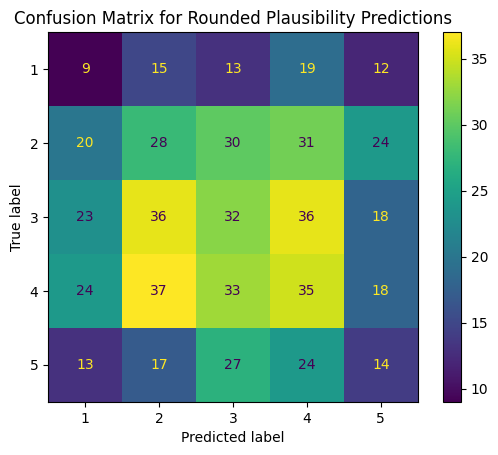

In [ ]:
cm = confusion_matrix(y_true_rounded, y_pred_rounded, labels=[1,2,3,4,5])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])
disp.plot()

plt.title("Confusion Matrix for Rounded Plausibility Predictions")
plt.savefig("confusion_matrix_dummy.png", dpi=300)
plt.show()

In [ ]:
def load_ambistory_json(path):
    """
    Loads AmbiStory json file and converts it into a pandas DataFrame.
    """
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []

    for key, item in data.items():
        full_story = (
            item["precontext"].strip() + " " +
            item["sentence"].strip() + " " +
            item["ending"].strip()
        ).strip()

        rows.append({
            "key": key,
            "sample_id": str(item["sample_id"]),
            "homonym": item["homonym"],
            "judged_meaning": item["judged_meaning"],
            "precontext": item["precontext"],
            "sentence": item["sentence"],
            "ending": item["ending"],
            "full_story": full_story,
            "story_length": len(full_story.split()),
            "average": float(item["average"]),
            "stdev": float(item["stdev"]),
            "choices": item["choices"]
        })

    return pd.DataFrame(rows)

In [ ]:
train_df = load_ambistory_json("train.json")
dev_df = load_ambistory_json("dev.json")

print("Train size:", train_df.shape)
print("Dev size:", dev_df.shape)

Train size: (2280, 12)
Dev size: (588, 12)


In [ ]:
def round_predictions(predictions):
    """
    Converts continuous predictions into discrete labels from 1 to 5.
    Example: 3.7 -> 4, 0.8 -> 1, 5.4 -> 5
    """
    predictions = np.asarray(predictions)
    rounded = np.rint(predictions)
    clipped = np.clip(rounded, 1, 5)
    return clipped.astype(int)

In [ ]:
def accuracy_at_std(y_true, y_pred, y_std):
    """
    Official Accuracy@std logic.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_std = np.asarray(y_std)

    inside_std_range = (y_true - y_std < y_pred) & (y_pred < y_true + y_std)
    within_one_point = np.abs(y_true - y_pred) < 1

    correct = inside_std_range | within_one_point

    return np.mean(correct)

In [ ]:
def compute_spearman(y_true, y_pred):
    """
    Computes Spearman rank correlation.
    """
    score, p_value = spearmanr(y_true, y_pred)

    if np.isnan(score):
        return 0.0

    return score

In [ ]:
def compute_classification_metrics(y_true, y_pred):
    """
    Computes macro precision, macro recall, and macro F1
    after rounding continuous scores to 1-5 integer labels.
    """
    y_true_rounded = round_predictions(y_true)
    y_pred_rounded = round_predictions(y_pred)

    macro_precision = precision_score(
        y_true_rounded,
        y_pred_rounded,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true_rounded,
        y_pred_rounded,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true_rounded,
        y_pred_rounded,
        average="macro",
        zero_division=0
    )

    return {
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save_path=None, normalize=False):
    """
    Plots confusion matrix for rounded 1-5 plausibility predictions.
    If normalize=True, rows are normalized to show percentages per true label.
    """
    y_true_rounded = round_predictions(y_true)
    y_pred_rounded = round_predictions(y_pred)

    labels = [1, 2, 3, 4, 5]

    cm = confusion_matrix(
        y_true_rounded,
        y_pred_rounded,
        labels=labels
    )

    if normalize:
        cm_display = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_display = np.nan_to_num(cm_display)
        display_values = cm_display.round(2)
        title = title + " (Row-Normalized)"
    else:
        display_values = cm

    disp = ConfusionMatrixDisplay(
        confusion_matrix=display_values,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax)

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return cm

In [ ]:
def evaluate_predictions(y_true, y_pred, y_std, model_name="Model"):
    """
    Computes all evaluation metrics for a given prediction array.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_std = np.asarray(y_std)

    acc_std = accuracy_at_std(y_true, y_pred, y_std)
    spearman = compute_spearman(y_true, y_pred)
    composite_score = (acc_std + spearman) / 2

    classification_results = compute_classification_metrics(y_true, y_pred)

    results = {
        "model": model_name,
        "accuracy_at_std": acc_std,
        "spearman": spearman,
        "composite_score": composite_score,
        "macro_precision": classification_results["macro_precision"],
        "macro_recall": classification_results["macro_recall"],
        "macro_f1": classification_results["macro_f1"]
    }

    return results

In [ ]:
def load_prediction_csv(prediction_path):
    """
    Loads model predictions from a CSV file.
    Expected columns: sample_id, prediction
    """
    pred_df = pd.read_csv(prediction_path)
    pred_df["sample_id"] = pred_df["sample_id"].astype(str)
    pred_df["prediction"] = pred_df["prediction"].astype(float)
    return pred_df

In [ ]:
def evaluate_prediction_file(dev_df, prediction_path, model_name="Model"):
    """
    Loads a prediction CSV, merges it with the validation set by sample_id,
    and evaluates the predictions.
    """
    pred_df = load_prediction_csv(prediction_path)

    eval_df = dev_df.merge(
        pred_df,
        on="sample_id",
        how="inner"
    )

    if len(eval_df) != len(dev_df):
        print(f"Warning: Expected {len(dev_df)} predictions, but got {len(eval_df)} matched rows.")

    y_true = eval_df["average"].values
    y_std = eval_df["stdev"].values
    y_pred = eval_df["prediction"].values

    results = evaluate_predictions(
        y_true=y_true,
        y_pred=y_pred,
        y_std=y_std,
        model_name=model_name
    )

    return results, eval_df

In [ ]:
train_mean_score = train_df["average"].mean()

mean_baseline_predictions = np.full(
    shape=len(dev_df),
    fill_value=train_mean_score
)

train_mean_score

y_true = dev_df["average"].values
y_std = dev_df["stdev"].values

mean_baseline_results = evaluate_predictions(
    y_true=y_true,
    y_pred=mean_baseline_predictions,
    y_std=y_std,
    model_name="Mean Baseline"
)

mean_baseline_results

C:\Users\hamza\AppData\Local\Temp\ipykernel_16188\3087724471.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  score, p_value = spearmanr(y_true, y_pred)


{'model': 'Mean Baseline',
 'accuracy_at_std': np.float64(0.5663265306122449),
 'spearman': 0.0,
 'composite_score': np.float64(0.28316326530612246),
 'macro_precision': 0.04931972789115646,
 'macro_recall': 0.2,
 'macro_f1': 0.0791268758526603}

In [ ]:
y_true = dev_df["average"].values
y_std = dev_df["stdev"].values

mean_baseline_results = evaluate_predictions(
    y_true=y_true,
    y_pred=mean_baseline_predictions,
    y_std=y_std,
    model_name="Mean Baseline"
)

mean_baseline_results

C:\Users\hamza\AppData\Local\Temp\ipykernel_16188\3087724471.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  score, p_value = spearmanr(y_true, y_pred)


{'model': 'Mean Baseline',
 'accuracy_at_std': np.float64(0.5663265306122449),
 'spearman': 0.0,
 'composite_score': np.float64(0.28316326530612246),
 'macro_precision': 0.04931972789115646,
 'macro_recall': 0.2,
 'macro_f1': 0.0791268758526603}

In [ ]:
np.random.seed(42)

random_baseline_predictions = np.random.uniform(
    low=1,
    high=5,
    size=len(dev_df)
)

random_baseline_results = evaluate_predictions(
    y_true=y_true,
    y_pred=random_baseline_predictions,
    y_std=y_std,
    model_name="Random Baseline"
)

random_baseline_results

{'model': 'Random Baseline',
 'accuracy_at_std': np.float64(0.48639455782312924),
 'spearman': np.float64(-0.019782232176276535),
 'composite_score': np.float64(0.23330616282342634),
 'macro_precision': 0.19057139127027498,
 'macro_recall': 0.18980651425724554,
 'macro_f1': 0.189633917176702}

In [ ]:
results_table = pd.DataFrame([
    mean_baseline_results,
    random_baseline_results
])

results_table
results_table.round(4)
results_table.to_csv("baseline_evaluation_results.csv", index=False)

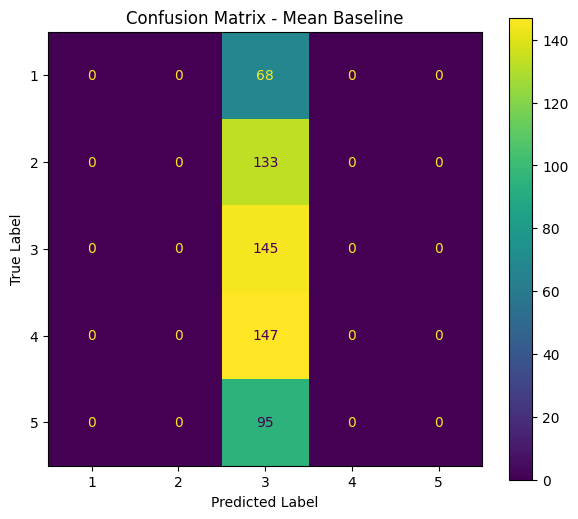

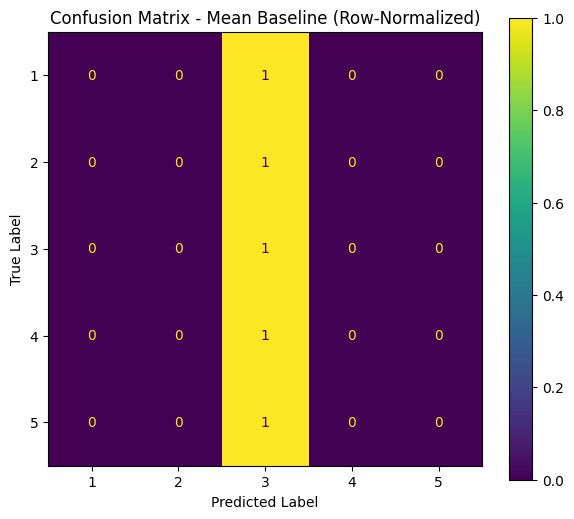

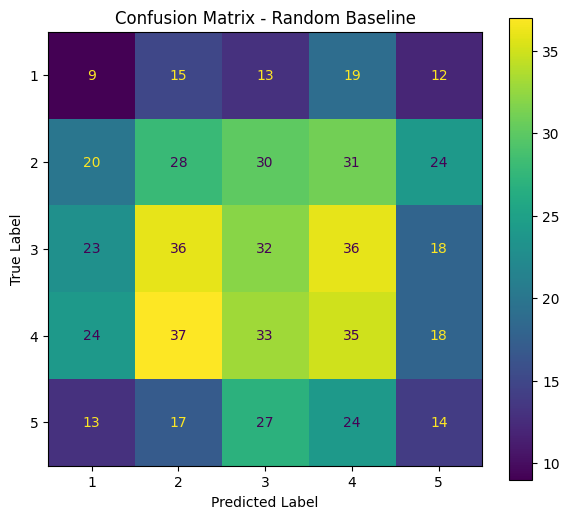

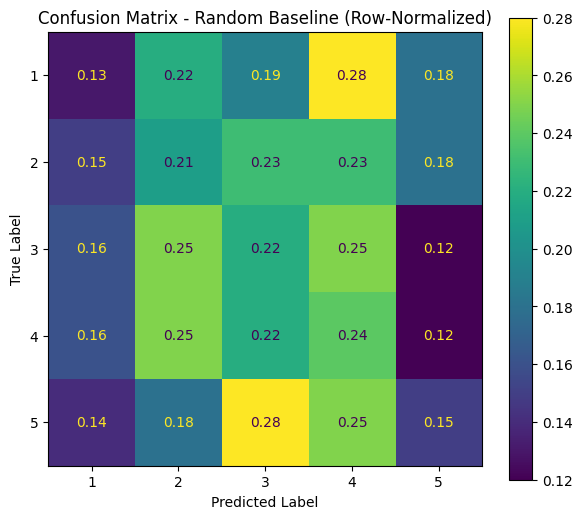

In [ ]:
# Mean baseline confusion matrix
cm_mean = plot_confusion_matrix(
    y_true=y_true,
    y_pred=mean_baseline_predictions,
    title="Confusion Matrix - Mean Baseline",
    save_path="confusion_matrix_mean_baseline.png",
    normalize=False
)

# Mean baseline normalized confusion matrix
cm_mean_norm = plot_confusion_matrix(
    y_true=y_true,
    y_pred=mean_baseline_predictions,
    title="Confusion Matrix - Mean Baseline",
    save_path="confusion_matrix_mean_baseline_normalized.png",
    normalize=True
)

# Random baseline confusion matrix
cm_random = plot_confusion_matrix(
    y_true=y_true,
    y_pred=random_baseline_predictions,
    title="Confusion Matrix - Random Baseline",
    save_path="confusion_matrix_random_baseline.png",
    normalize=False
)

# Random baseline normalized confusion matrix
cm_random_norm = plot_confusion_matrix(
    y_true=y_true,
    y_pred=random_baseline_predictions,
    title="Confusion Matrix - Random Baseline",
    save_path="confusion_matrix_random_baseline_normalized.png",
    normalize=True
)


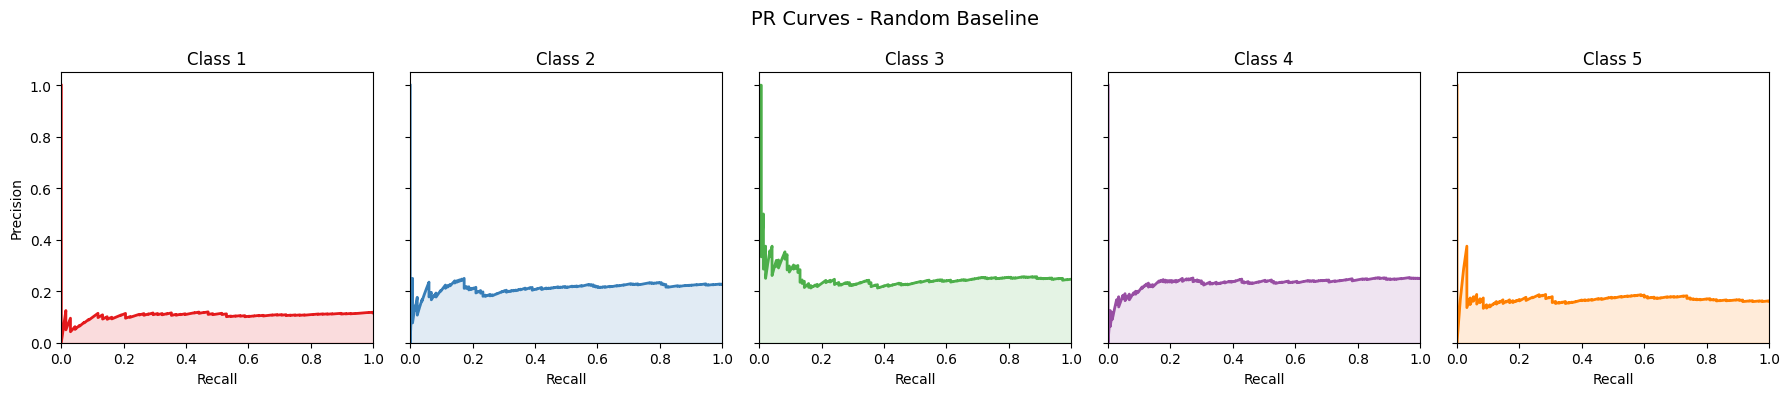

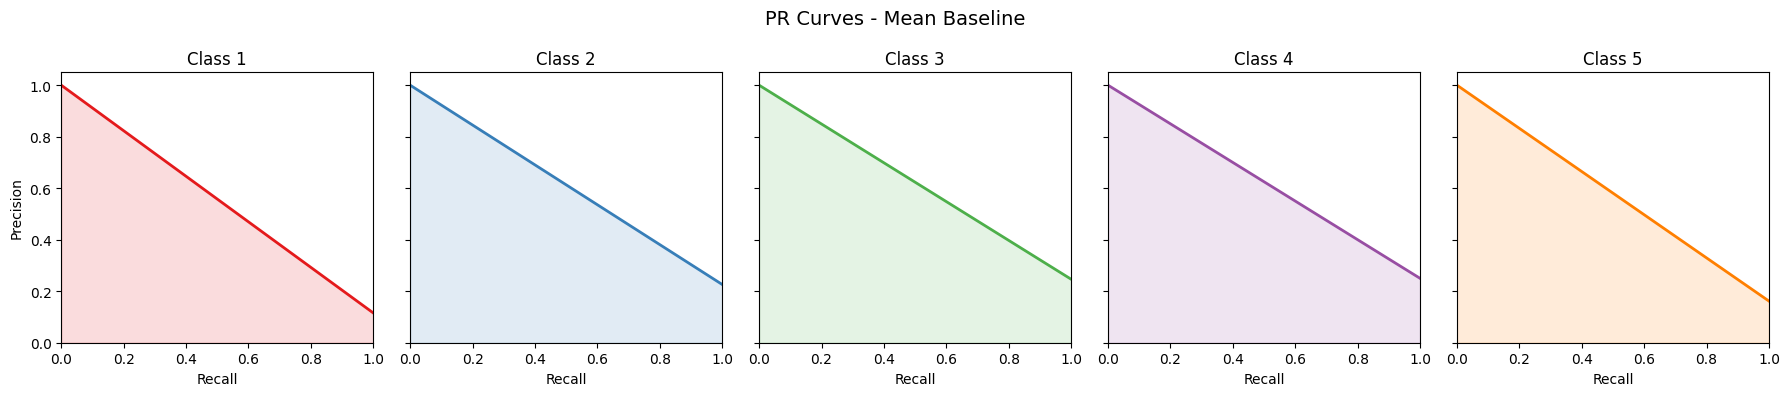

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

def plot_pr_curves(y_true, y_pred, title="Precision-Recall Curves", save_path=None):
    y_true_rounded = round_predictions(y_true)
    y_pred_rounded = round_predictions(y_pred)

    classes = [1, 2, 3, 4, 5]
    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

    for cls, color, ax in zip(classes, colors, axes):
        binary_gold = (y_true_rounded == cls).astype(int)
        # Score: tahmin ne kadar o sınıfa yakın
        scores = 5 - np.abs(y_pred - cls)

        prec, rec, _ = precision_recall_curve(binary_gold, scores)
        ax.plot(rec, prec, color=color, lw=2)
        ax.fill_between(rec, prec, alpha=0.15, color=color)
        ax.set_title(f"Class {cls}", fontsize=12)
        ax.set_xlabel("Recall")
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.05])

    axes[0].set_ylabel("Precision")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Run:
plot_pr_curves(y_true, random_baseline_predictions,
               title="PR Curves - Random Baseline",
               save_path="pr_curves_random_baseline.png")

plot_pr_curves(y_true, mean_baseline_predictions,
               title="PR Curves - Mean Baseline",
               save_path="pr_curves_mean_baseline.png")